In [12]:
import os
os.environ['TANGOS_SIMULATION_FOLDER'] = '../'
import tangos as db

db.init_db("./data.db")



In [18]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as p
import numpy as np
import flamingo_analysis as fa 


In [21]:
dbid, m200, accrate, eflow = db.get_timestep("L0200N0360_HYDRO_FIDUCIAL/%7%").calculate_all('dbid()', 'M200m()', 
                 '0.0102 * InclusiveSphere_30kpc_MostMassiveBlackHoleAccretionRate', 'at(-1.0, gas_energy_outflow_r200m_relative)'
)

In [99]:
mask = (m200 > 2e13) & (m200<2.2e13)

Text(0, 0.5, 'Energy outflow rate at 0.1 r200m [erg/s]')

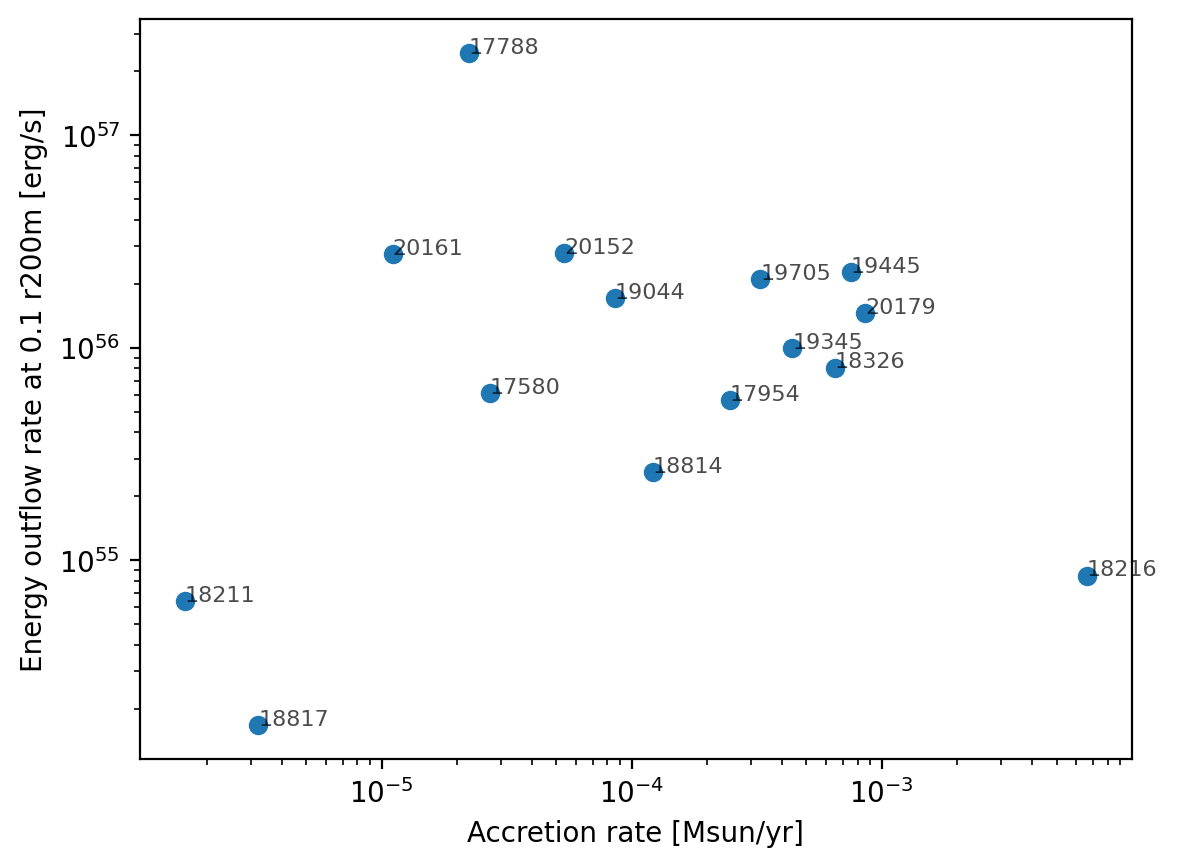

In [106]:
p.figure()
p.plot(accrate[mask], eflow[mask], 'o')
for i, dbid_val in enumerate(dbid[mask]):
    p.text(accrate[mask][i], eflow[mask][i], str(dbid_val), fontsize=8, alpha=0.7)
p.loglog()
p.xlabel("Accretion rate [Msun/yr]")
p.ylabel("Energy outflow rate at 0.1 r200m [erg/s]")



In [ ]:
ts_keepalive = db.get_timestep("L0200N0360_HYDRO_FIDUCIAL/%7%").load()


In [101]:
import pynbody

In [145]:
def make_image(h, h_obj, width='1.0 Mpc'):
    pynbody.plot.sph.velocity_image(h.ancestor.g, qty='temp', width=width, key_length='1000 km s**-1', cmap='RdBu_r', clear=False,
                                    vmin=1e5, vmax=2e7)
    r200m = h_obj['r200m']
    circle1 = p.Circle((0, 0), r200m, fill=False, color='white', linewidth=2)
    circle2 = p.Circle((0, 0), 0.1 * r200m, fill=False, color='white', linewidth=2)
    p.gca().add_patch(circle1)
    p.gca().add_patch(circle2)
    p.grid()

def plot_feedback_timescale_distribution(h, radius):
    p.hist(h[pynbody.filt.Sphere(radius)].gas['LastAGNFeedbackScaleFactors'], bins=200, cumulative=-1, density=True,
          histtype='step')
    p.axvline(h.properties['a'], color='red', linestyle=':')
    p.xlabel("Scalefactor")
    p.ylabel("Fraction heated this recently")
    p.xlim(0.5, 1.0)
    p.ylim(0, 0.3)
    
def make_image_panels(h_obj, with_heating_timescale=True):
    if isinstance(h_obj, int):
        h_obj = db.get_halo(h_obj)
    h = h_obj.load()
    with pynbody.analysis.halo.center(h):
        if with_heating_timescale:
            p.figure(figsize=(15,5))
            p.subplot(131)
        else:
            p.figure(figsize=(10,5))
            p.subplot(121)
        make_image(h, h_obj, width=2.2*h_obj['r200m'])
        if with_heating_timescale:
            p.subplot(132)
        else:
            p.subplot(122)
        make_image(h, h_obj, width=0.22*h_obj['r200m'])
        if with_heating_timescale:
            p.subplot(133)
            plot_feedback_timescale_distribution(h, h_obj['r200m'])
    p.suptitle(f"dbid={h_obj.id}, $M_{{200m}}$={h_obj.calculate("M200m()"):.1e}, $\dot{{M}}_{{BH}}$={h_obj.calculate('0.0102 * InclusiveSphere_30kpc_MostMassiveBlackHoleAccretionRate'):.1e} $M_\\odot/yr$, $E_{{outflow}}$={h_obj.calculate('at(-1.0, gas_energy_outflow_r200m_relative)'):.1e} erg/Myr")
    p.tight_layout()



<>:40: SyntaxWarning: invalid escape sequence '\d'
<>:40: SyntaxWarning: invalid escape sequence '\d'
/var/folders/vk/zg9_2k_512l3syhc8kdzkzwm0000gp/T/ipykernel_88262/2325507638.py:40: SyntaxWarning: invalid escape sequence '\d'
  p.suptitle(f"dbid={h_obj.id}, $M_{{200m}}$={h_obj.calculate("M200m()"):.1e}, $\dot{{M}}_{{BH}}$={h_obj.calculate('0.0102 * InclusiveSphere_30kpc_MostMassiveBlackHoleAccretionRate'):.1e} $M_\\odot/yr$, $E_{{outflow}}$={h_obj.calculate('at(-1.0, gas_energy_outflow_r200m_relative)'):.1e} erg/Myr")


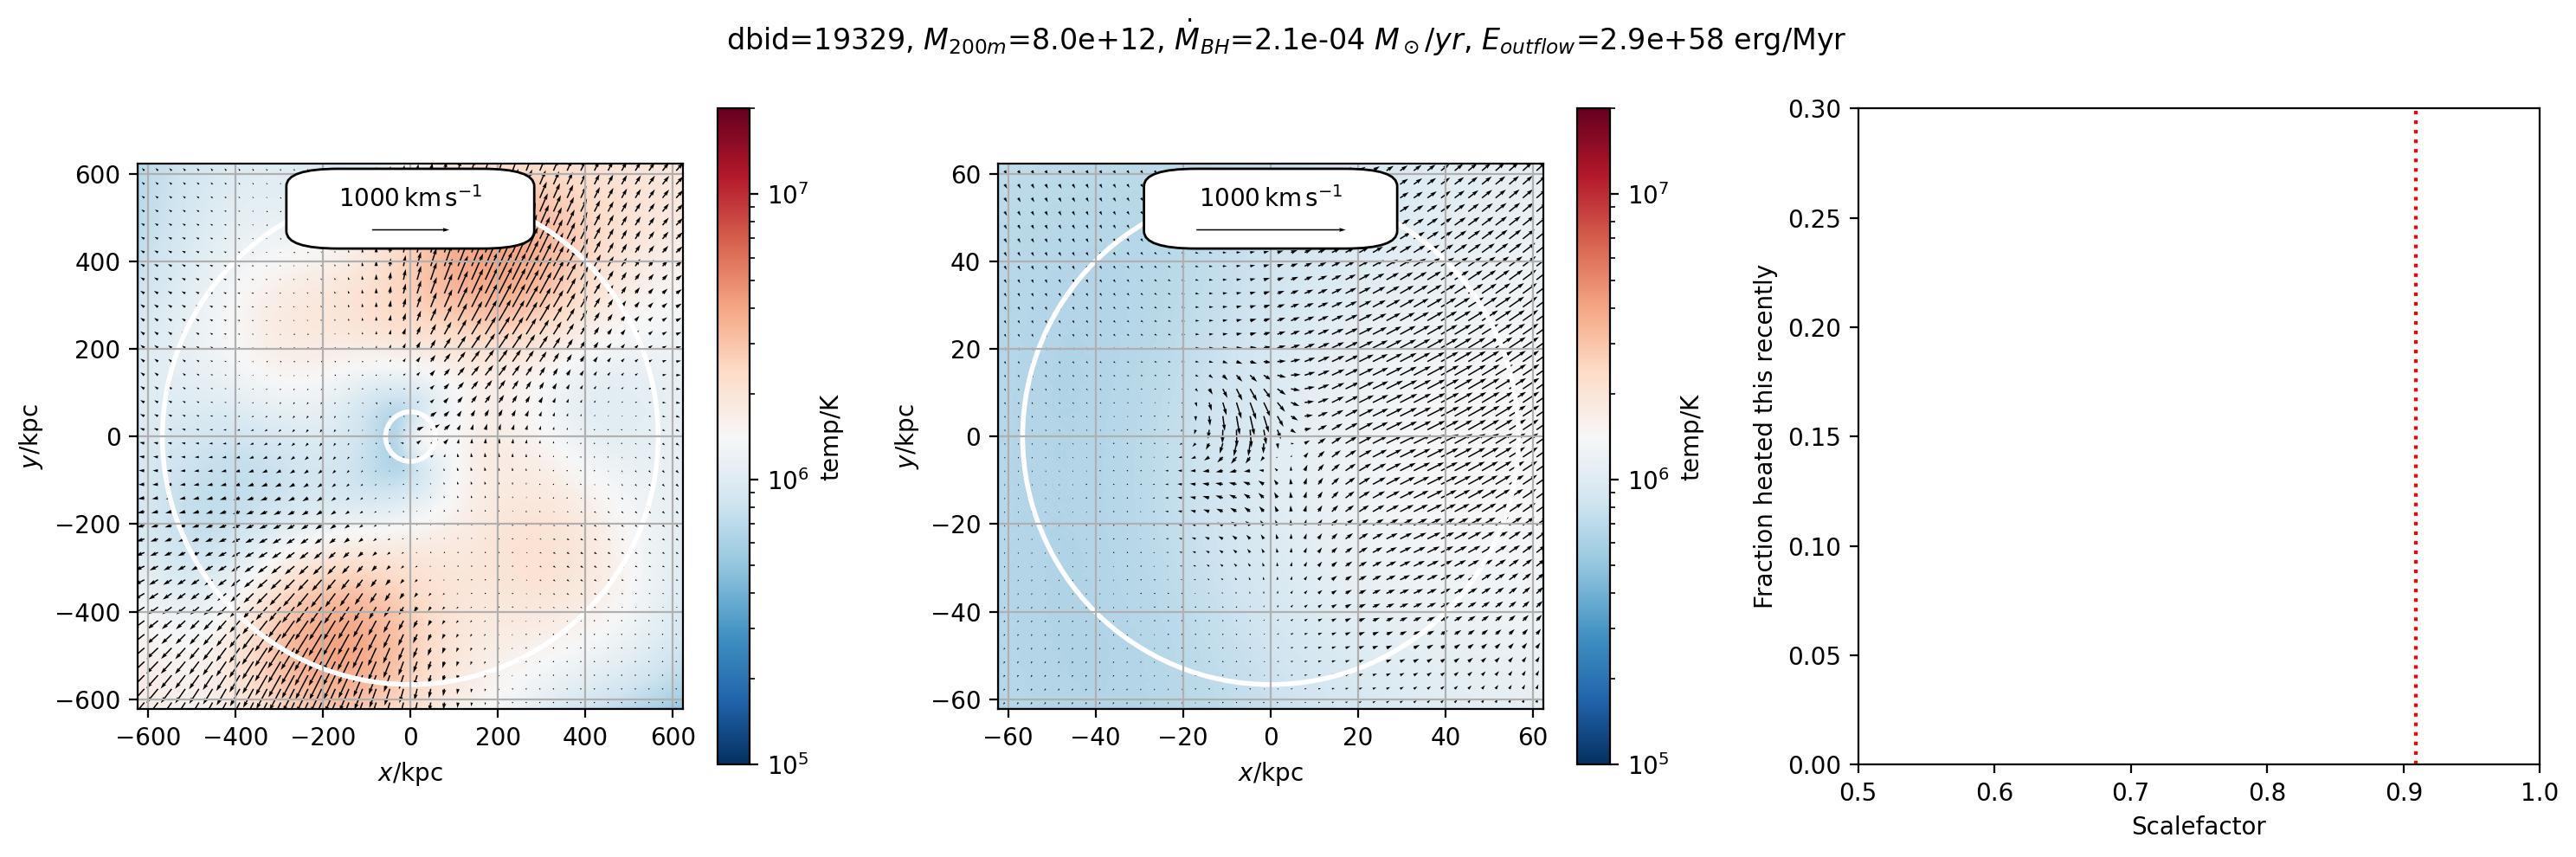

In [140]:
make_image_panels(19329)

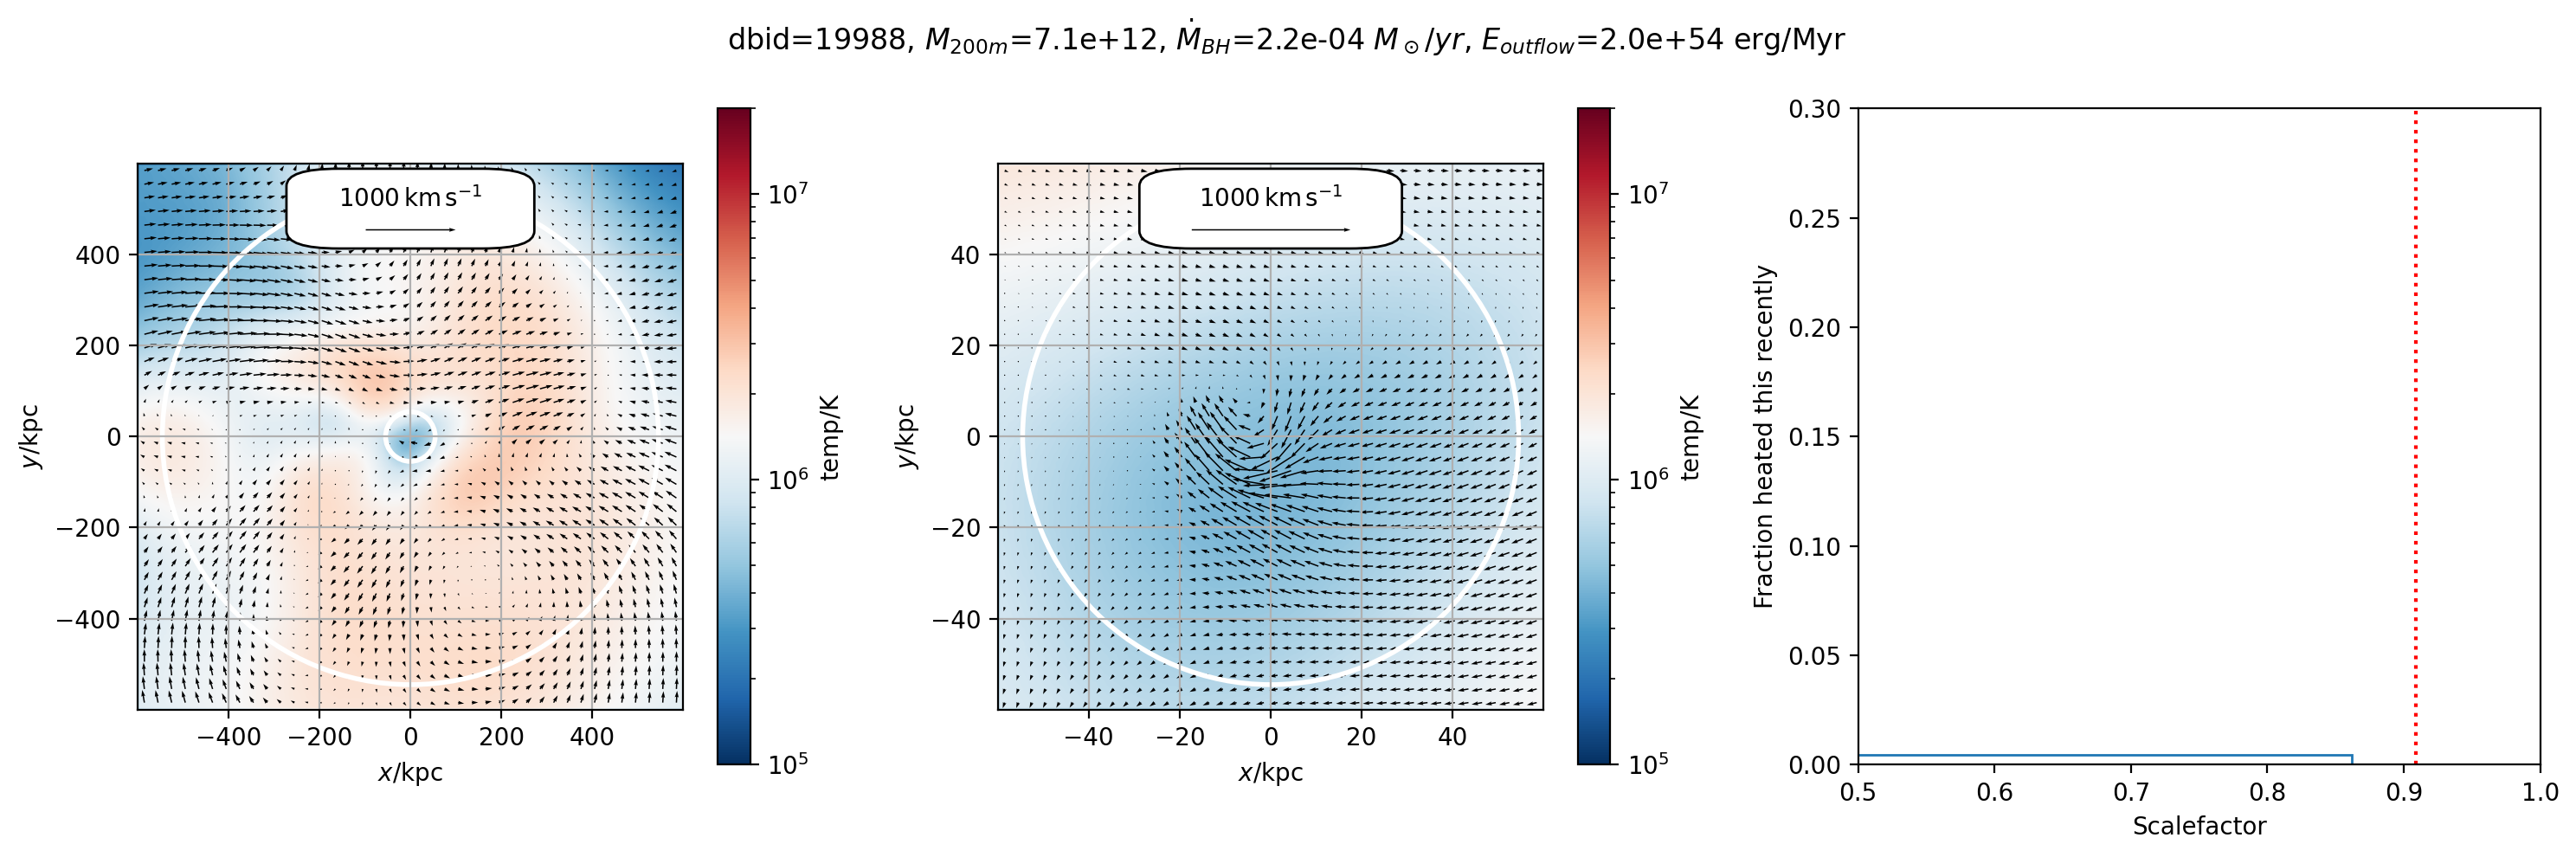

In [141]:
make_image_panels(19988)

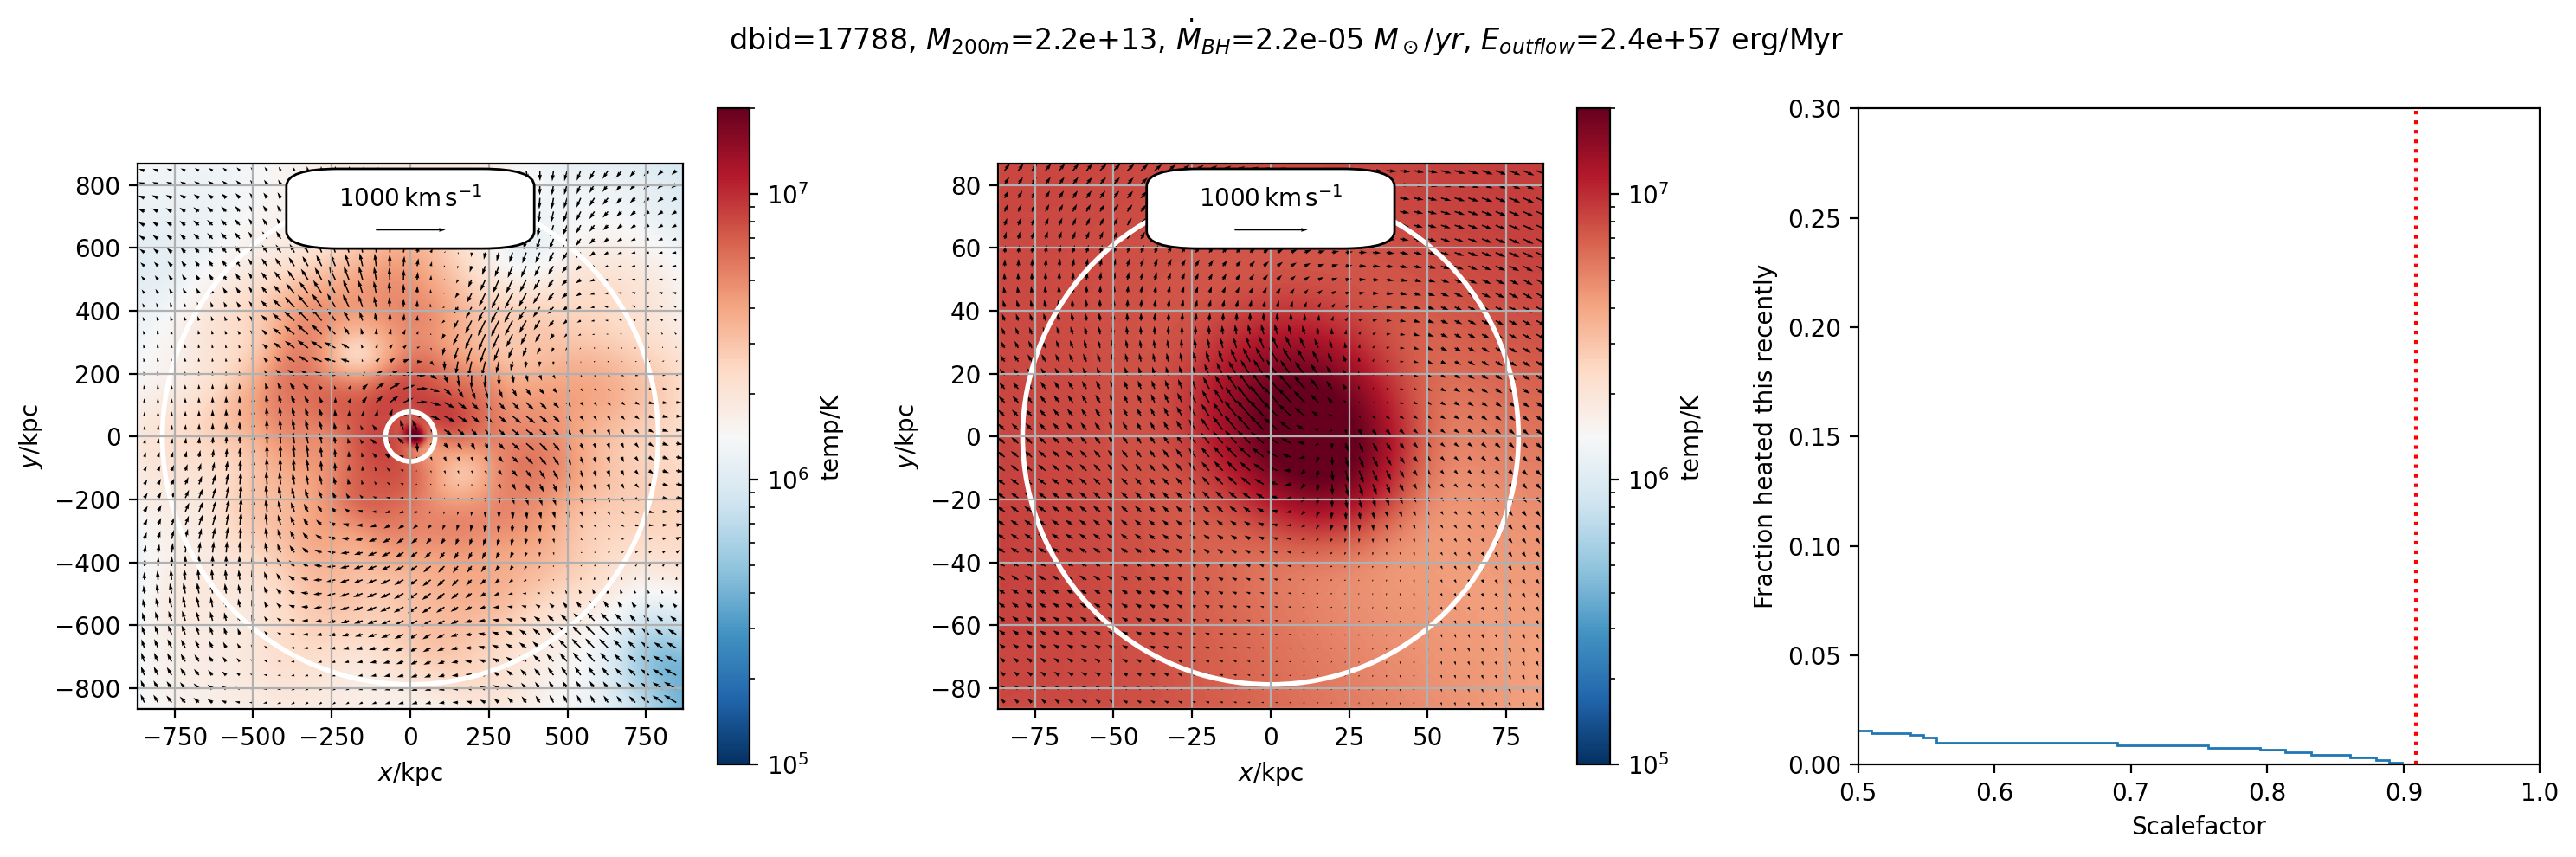

In [142]:
make_image_panels(17788)

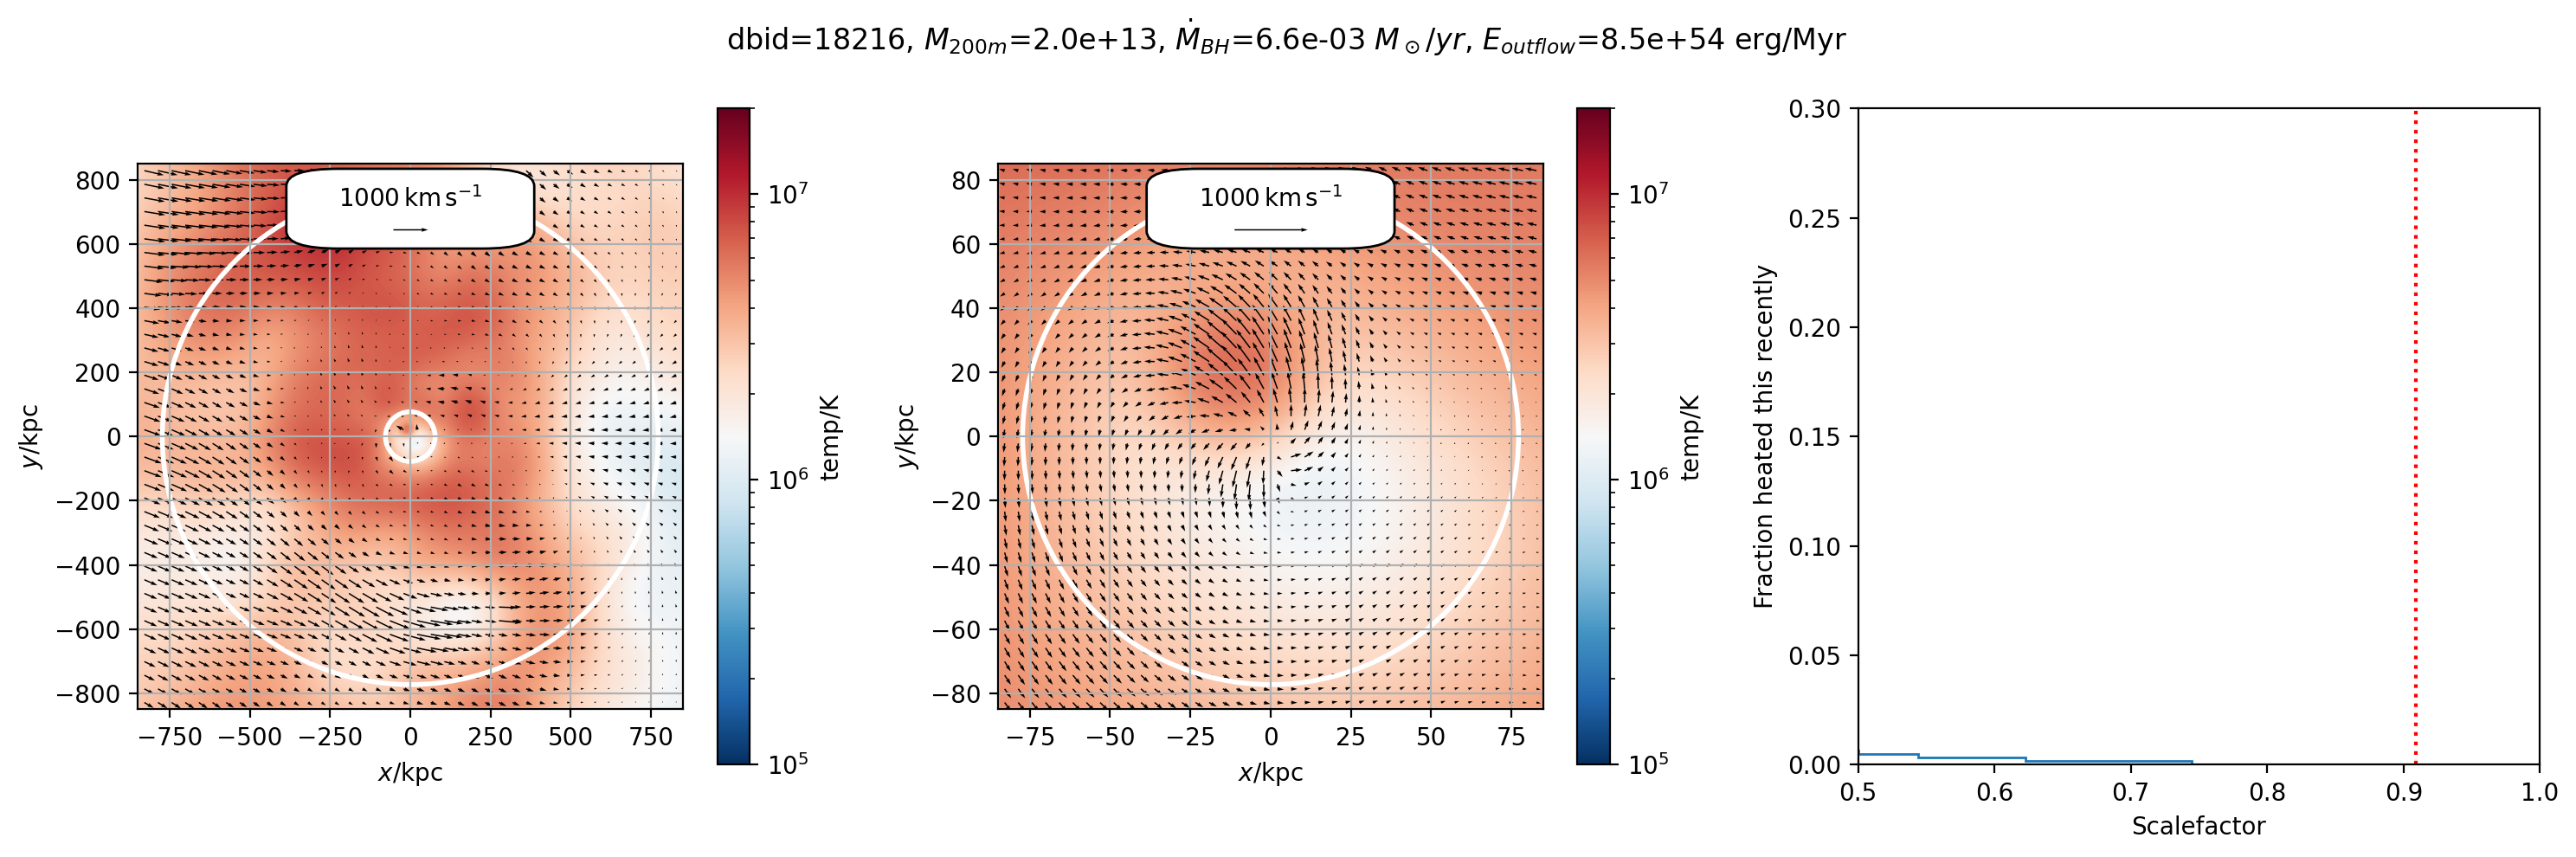

In [143]:
make_image_panels(18216)

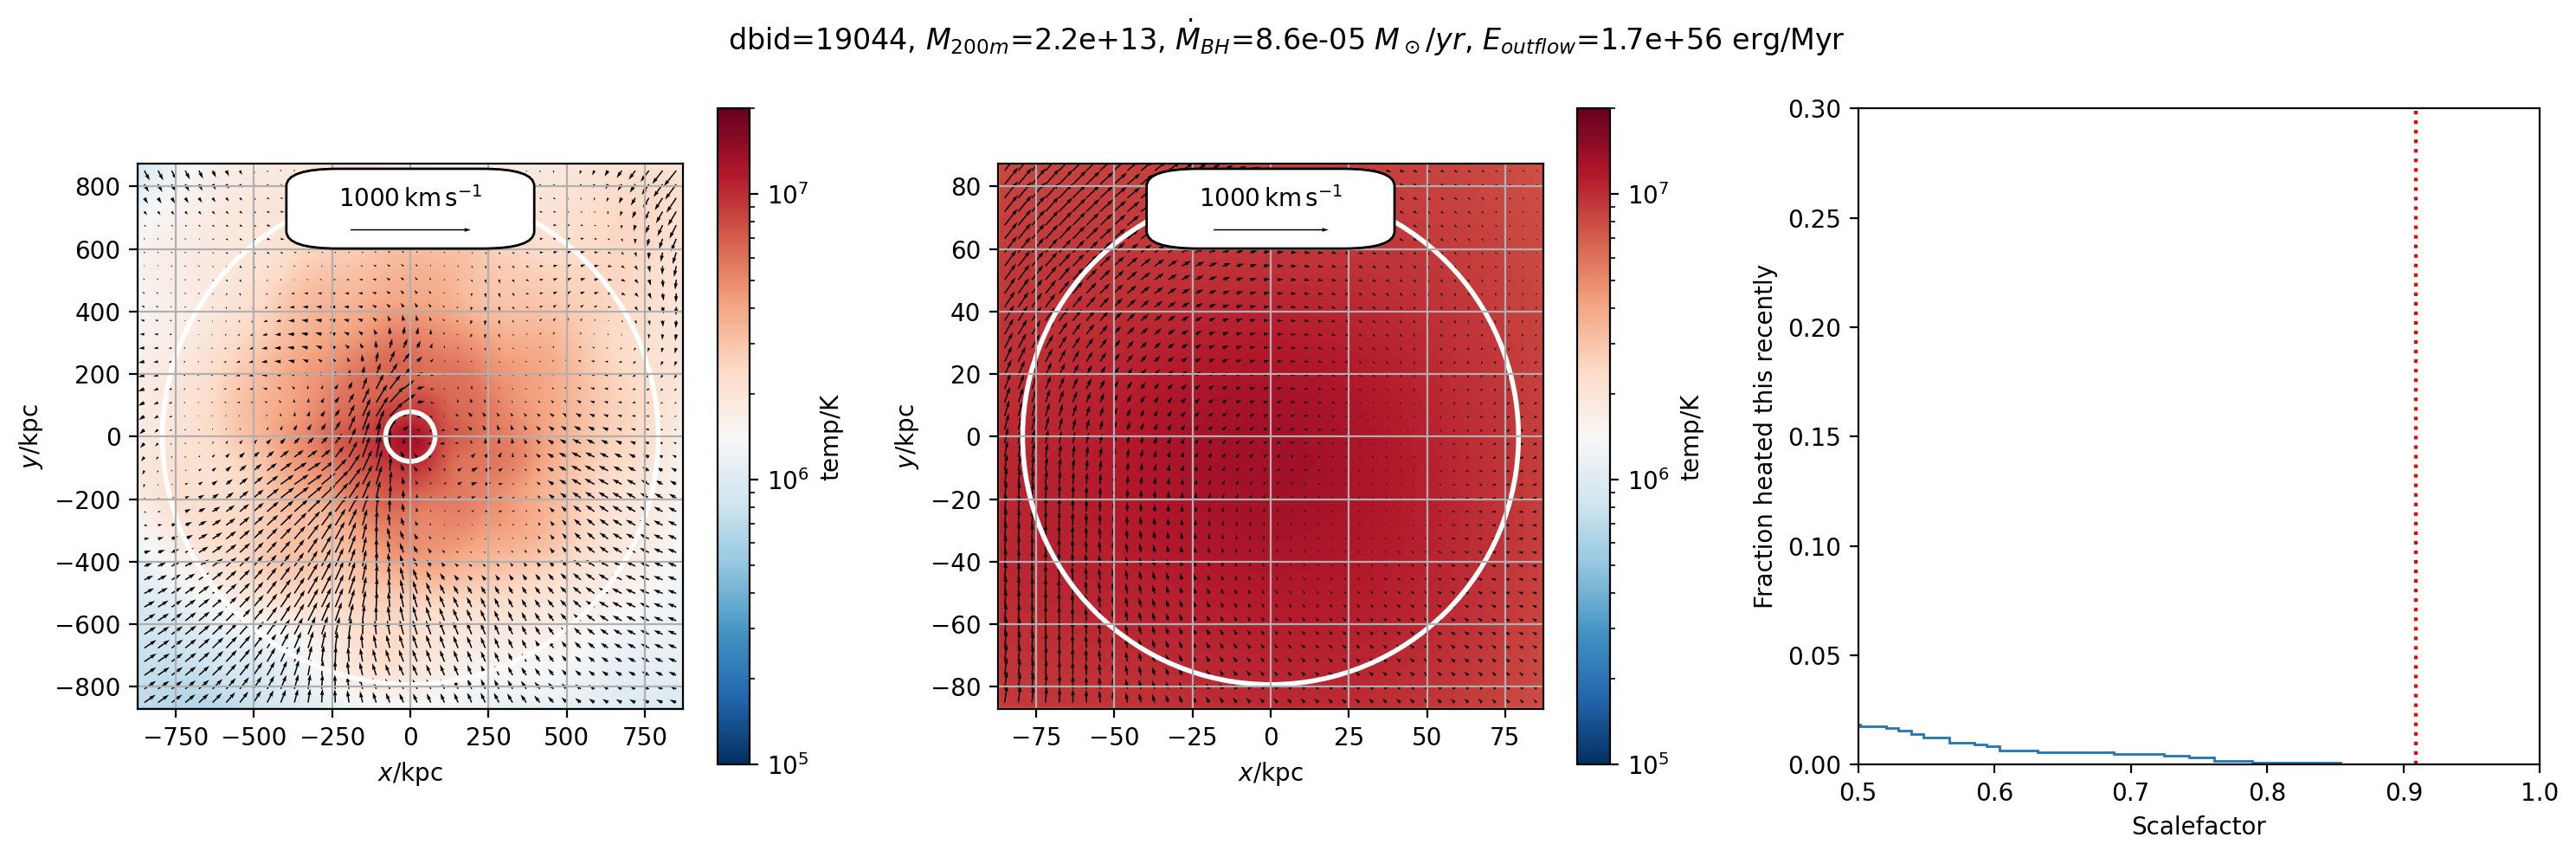

In [147]:
make_image_panels(19044)